# When AI Learns the Wrong Thing: Auditing Name Bias in a Salary Prediction Model

For help with this notebook, contact Dennis Kane dkane@elcamino.edu

## AI and Ethics Lab

This lab uses a **synthetic dataset** containing many different people. Two names are deliberately important:

- **Bob:** many people named Bob receive an artificial salary penalty in the historical data, even when their qualifications are similar to other people.
- **Ray:** many people named Ray tend to have less experience. Ray receives **no direct salary penalty** for his name, but will coincidentally have a low salary.

The central question is:

> Can an AI learn an unfair relationship from its training data, and how can we audit what the model learned?

**Important:** The relationships involving names are fictional and were created only for this instructional exercise.

## Learning Objectives

By the end of this lab, you should be able to:

1. Train an AI model to predict a target value, in this case salary.
2. Use counterfactual testing to investigate a prediction.
3. Use SHAP to examine feature contributions.
4. Distinguish a direct unjustified relationship from a correlation involving another explanatory variable.
5. Explain why an AI explanation does not automatically prove that a decision is fair.

In [ ]:
!pip -q install shap

In [ ]:
# Bring in the libraries and packages needed for this lab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap

# Provide seed for reproducibility
RANDOM_STATE = 42

# Part 1 — Load the Dataset

In Google Colab, upload `bob_ray_salary_data.csv` when prompted.

In [ ]:
# The dataset is pulled into this folder along with the notebook
df = pd.read_csv("bob_ray_salary_data.csv")
display(df.head())

# Let's see what the data looks like
print("Dataset shape:", df.shape)
print("\nName counts:")
print(df["name"].value_counts())

print("\nAverage experience and salary by name:")
display(df.groupby("name")[["experience_years","salary"]].mean().round(1))

## Question 1

Before training the model:

1. Do candidates named Bob or Ray both appear to have lower average salaries across the dataset? Note that there are many Bobs and Rays in the data.
2. Does either Bob or Ray also have lower average experience?
3. Can averages alone prove that an AI model is treating a group unfairly?

Write your answers before continuing.

# Part 2 — Train the Salary Prediction Model

The model will initially use all available features, including **name**.

In [ ]:
# Capture the features (what the moel will use to make predictions)
X = df.drop(columns="salary")
# Capture the target (what the model will be predicting)
y = df["salary"]

# Give the data an 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

# Indicate data types for the features
categorical = ["name","education","gender","race"]
numeric = ["age","experience_years"]

# Make the data digestible for training
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ("num", "passthrough", numeric)
])

# Training the brain
model = RandomForestRegressor(
    n_estimators=250, random_state=RANDOM_STATE, min_samples_leaf=2)

# A Pipeline links sequential steps into a single automated workflow.
# Step 1 ("preprocessor"): Translates raw text and numbers into math-ready inputs (e.g., One-Hot Encoding names/categories).
# Step 2 ("model"): Takes those prepared inputs and uses the Random Forest algorithm to predict the target (salary).
# Combining them ensures every person's data is transformed and evaluated using the exact same rules without manual errors.
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

# Evaluate how accurately the model predicts salaries on unseen test data

# MAE: On average, how many dollars off are the model's predictions?
# Lower is better. A MAE of $5,668 means predictions miss actual salaries by ~$5,668 on average.
print(f"Mean Absolute Error: ${mean_absolute_error(y_test, pred):,.0f}")

# R² Score: How much of the variation in salaries does the model actually explain?
# Ranges from 0 (useless model) to 1 (perfect model). 0.888 means the model explains ~88.8% of salary differences.
print(f"R² Score: {r2_score(y_test, pred):.3f}")

Mean Absolute Error: $5,668
R² Score: 0.888


# Part 3 — Counterfactual Test: Bob vs. John

A counterfactual test changes **one thing** while holding everything else constant.

Bob and John below have identical qualifications. Only their names differ so the model should predict the same salary.

In [ ]:
# --- STEP 1: Construct a single test scenario ("Bob") ---
# Instead of pulling one of the 150 Bobs from the dataset (who all have different ages and experience),
# we build ONE standardized test profile with fixed qualifications (15 yrs exp, Bachelor's, Age 40).
bob_test_case = pd.DataFrame([{
    "name": "Bob", "age": 40, "education": "Bachelor",
    "experience_years": 15, "gender": "Male", "race": "Group A"
}])

# --- STEP 2: Create a counterfactual test scenario ("John") ---
# We make an exact clone of our standardized test case above...
john_test_case = bob_test_case.copy()
# ...and swap ONLY the name to "John" while keeping every qualification identical.
john_test_case.loc[0, "name"] = "John"

# --- STEP 3: Pass both test scenarios through the trained model ---
# Predict the salary outputs for each profile using the exact same pipeline rules[cite: 1].
bob_salary = pipeline.predict(bob_test_case)[0]
john_salary = pipeline.predict(john_test_case)[0]

# --- STEP 4: Display the results and calculate the systemic name penalty ---
# Print the predicted salaries formatted as whole dollar amounts[cite: 1].
print(f"Bob:  ${bob_salary:,.0f}")
print(f"John: ${john_salary:,.0f}")

# A non-zero difference proves the model penalizes the name "Bob" specifically,
# holding all real-world qualifications equal[cite: 1].
print(f"Difference: ${john_salary - bob_salary:,.0f}")

Bob:  $64,446
John: $84,518
Difference: $20,072


## Question 2 — Bob

This Bob and John pair differ only in name.

1. Did the prediction change?
2. What evidence does this provide about model behavior?
3. Is it ethically appropriate for salary prediction to change merely because the subject's name changed?

Remember: this experiment provides evidence about **what the model does**. Ethical judgment requires interpretation.

# Part 4 — Counterfactual Test: Ray vs. John

Now perform the same test using Ray.

Remember: people named Ray were generated with lower experience on average, but the data-generation formula did **not** directly subtract money because the subjects are named Ray.

In [ ]:
# --- STEP 1: Create a counterfactual test scenario for "Ray" ---
# Make an exact clone of our standardized "Bob" test case (15 yrs exp, Bachelor's, Age 40)...
ray_test_case = bob_test_case.copy()
# ...and swap ONLY the name to "Ray" while keeping every qualification identical.
ray_test_case.loc[0, "name"] = "Ray"

# --- STEP 2: Pass the Ray test scenario through the trained model ---
# Predict the salary output using the exact same pipeline rules[cite: 1].
ray_salary = pipeline.predict(ray_test_case)[0]

# --- STEP 3: Display the results and compare against John ---
# Print the predicted salaries formatted as whole dollar amounts[cite: 1].
print(f"Ray:  ${ray_salary:,.0f}")
print(f"John: ${john_salary:,.0f}")

# Unlike Bob, the difference here is negligible (~$139) because the model does NOT apply a direct salary penalty to the name "Ray" when qualifications are equal[cite: 1].
print(f"Difference: ${john_salary - ray_salary:,.0f}")

Ray:  $84,379
John: $84,518
Difference: $139


## Question 3 — Ray

1. Did Ray's name change the prediction?
2. What relationship exists between Ray and experience in the dataset?
3. If the model already knows a person's actual experience, should it also use the name as a statistical shortcut for experience?

This is the key distinction between the Bob and Ray cases.

# Part 5 — SHAP: What Does the Model Say Influenced Its Prediction?

## Important Ethical Distinction

> **SHAP reveals how a model makes predictions, but interpretability alone does not establish whether a model is fair or unfair.**

SHAP helps answer:

> **Which features contributed to this prediction?**

It does not, by itself, answer:

> **Was this prediction ethically justified?**

We will use SHAP together with counterfactual testing.

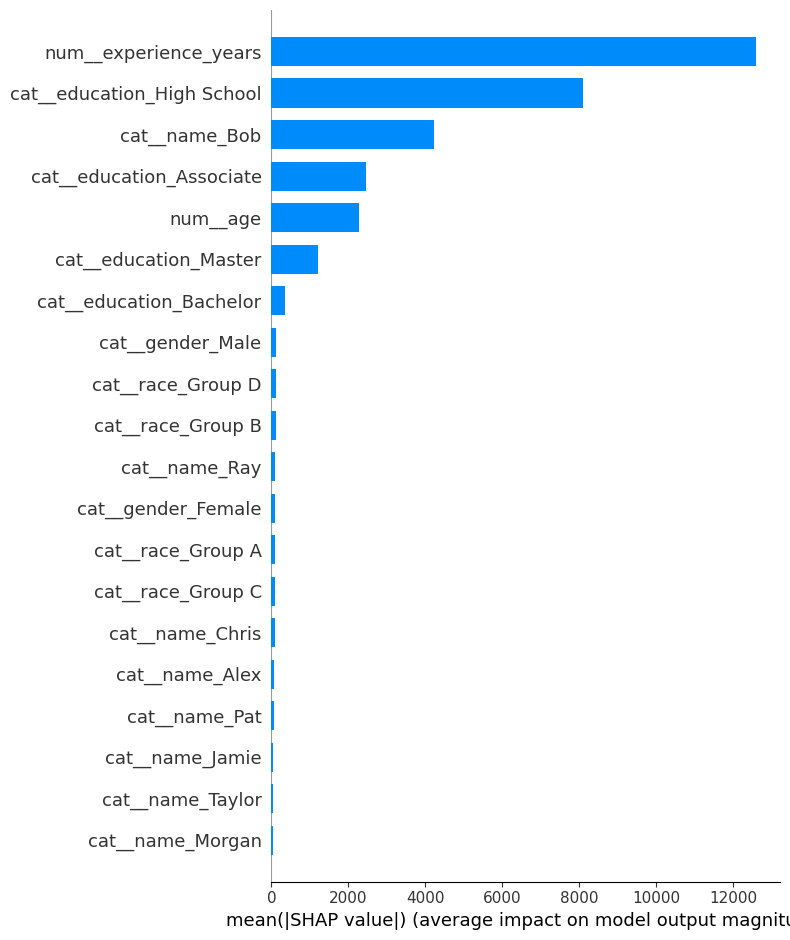

In [ ]:
# --- STEP 1: Unpack the pipeline components ---
# Extract the individual steps from our trained pipeline object:
# 'prep' gives us access to the data transformer, and 'rf' gives us the Random Forest algorithm.
prep = pipeline.named_steps["preprocessor"]
rf = pipeline.named_steps["model"]

# --- STEP 2: Format the test dataset for SHAP ---
# Apply the exact same encoding and scaling to the test set so the model can read it.
X_test_t = prep.transform(X_test)
# Extract readable text labels (e.g., "cat__name_Bob", "num__experience_years") for each column[cite: 1].
feature_names = prep.get_feature_names_out()

# --- STEP 3: Calculate SHAP values ---
# Create an explainer tool specifically designed for tree-based models like Random Forests[cite: 1].
explainer = shap.TreeExplainer(rf)
# Calculate feature attribution values for every single prediction in our transformed test dataset[cite: 1].
# This measures how much each feature pushes predictions up or down relative to the average baseline[cite: 1].
shap_values = explainer.shap_values(X_test_t)

# --- STEP 4: Visualize overall feature importance ---
# Plot a bar chart showing the average impact magnitude of each feature across all test predictions[cite: 1].
# Note for students: Higher bars show which features the model relies on most, NOT whether those features are fair or unfair[cite: 1].
shap.summary_plot(
    shap_values, X_test_t,
    feature_names=feature_names,
    plot_type="bar"
)

## Question 4 — Global SHAP Results

1. Are name-related features important to the model?
2. Is experience important?
3. What does feature importance tell you?
4. What can feature importance **not** tell you about fairness?

# Part 6 — Individual SHAP Explanations

Now examine Bob, Ray, and John individually.

Bob Test Profile


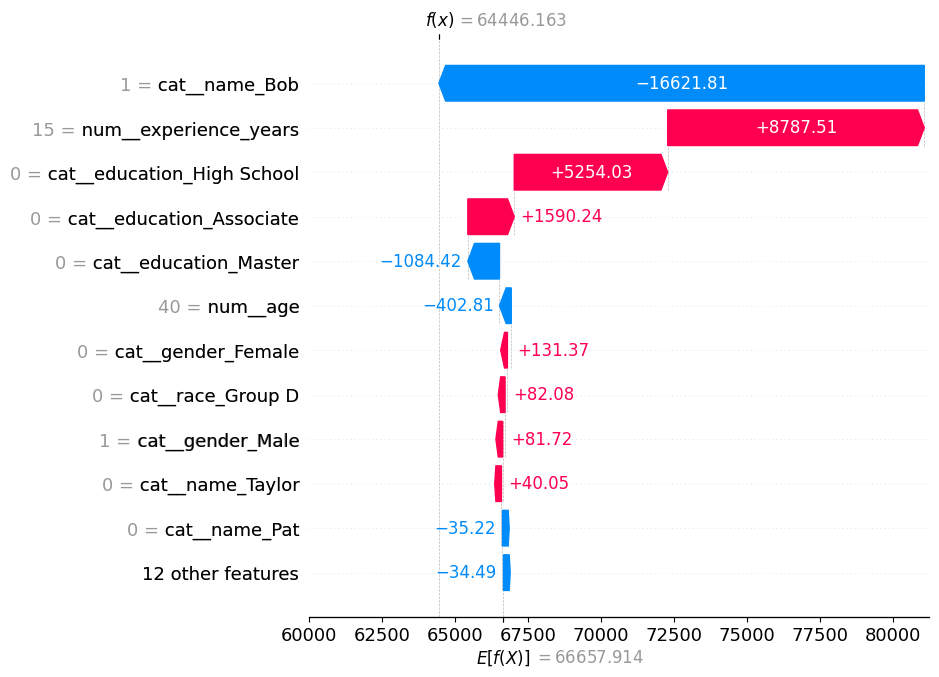

In [ ]:
# --- STEP 1: Define a helper function to explain a single individual's prediction ---
def explain(person, label):
    transformed = prep.transform(person)
    values = explainer.shap_values(transformed)

    explanation = shap.Explanation(
        values=values[0],
        base_values=explainer.expected_value,
        data=transformed[0],
        feature_names=feature_names
    )

    print(label)

    # 1. Generate plot without showing
    shap.plots.waterfall(explanation, max_display=12, show=False)

    # 2. Force every hidden axis SHAP creates to start at 60,000
    for ax in plt.gcf().axes:
        _, right_bound = ax.get_xlim()
        ax.set_xlim(60000, right_bound)

    # 3. Display the final plot
    plt.show()

# --- STEP 2: Run the explanation for our standardized benchmark profile ---
explain(bob_test_case, "Bob Test Profile")

Ray Test Profile


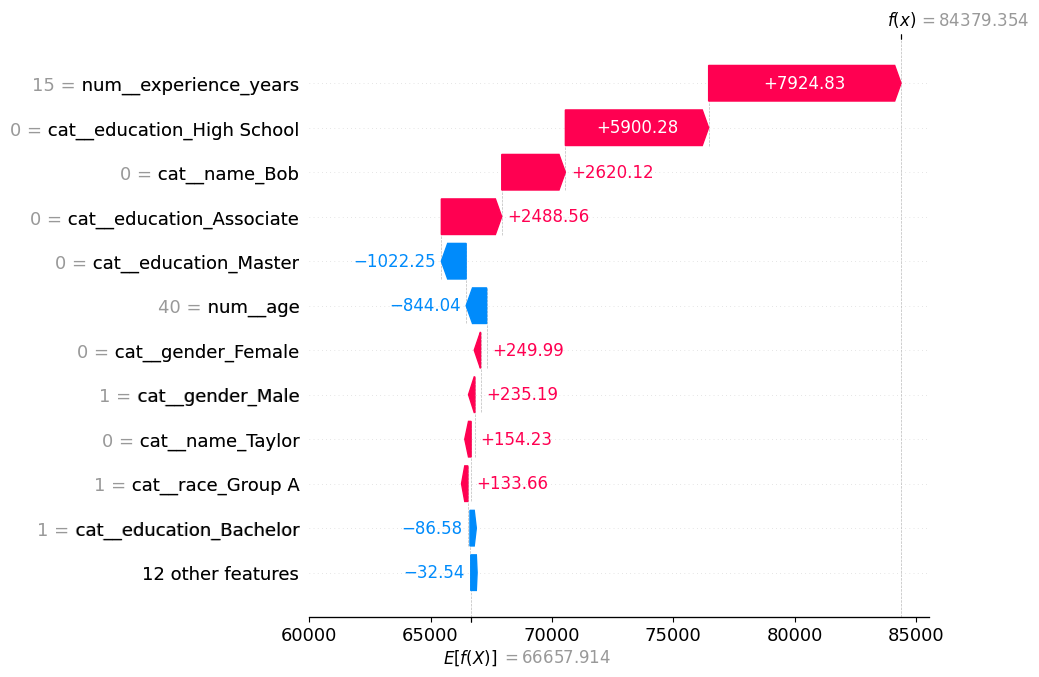

In [ ]:
# --- STEP 2: Run the explanation for our standardized "Ray" benchmark profile ---
# We pass our controlled test case ("ray_test_case") to see how the model
# treats a candidate named Ray with these exact same qualifications (15 yrs exp, Bachelor's, Age 40).
# This allows students to compare Ray's feature contributions directly against Bob's.
explain(ray_test_case, "Ray Test Profile")

John Test Profile


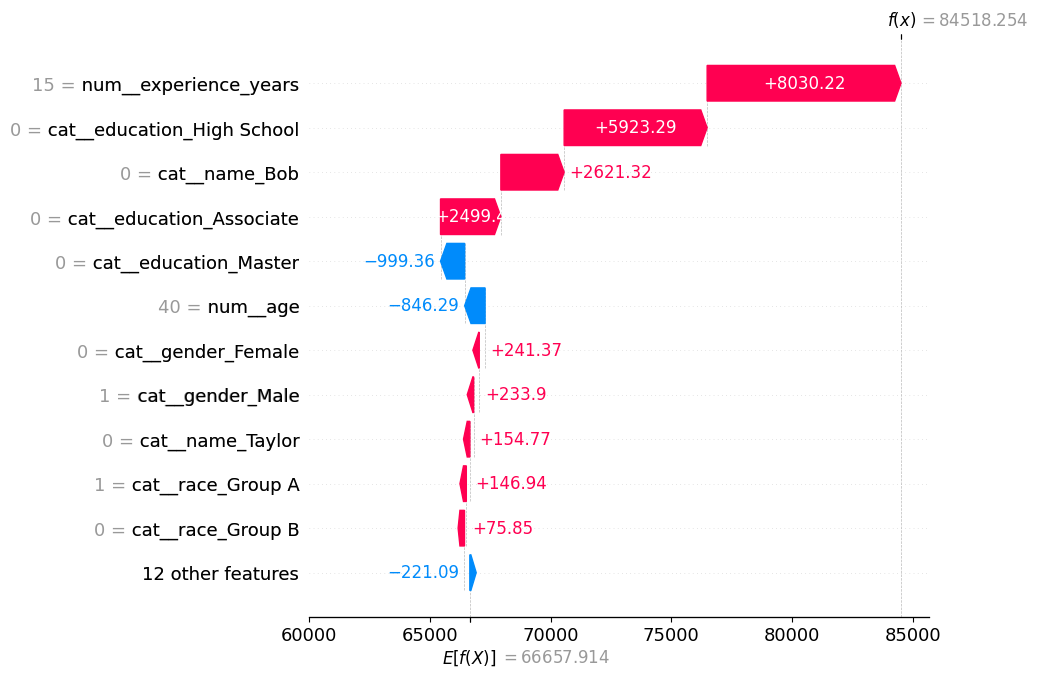

In [ ]:
# --- STEP 3: Run the explanation for our standardized "John" benchmark profile ---
# We pass our controlled test case ("john_test_case") to establish our baseline control group.
# John has the exact same qualifications (15 yrs exp, Bachelor's, Age 40) as Bob and Ray,
# but carries a neutral/unpenalized name category.
explain(john_test_case, "John Test Profile")

## Question 5 — What Did SHAP Add?

Compare the two audit methods.

### Counterfactual testing asks:

> What happens if I change one feature?

### SHAP asks:

> How did the model attribute this prediction among its features?

Discuss:

1. What did SHAP reveal about subjects named "Bob?"
2. What did SHAP reveal about subjects named "Ray?"
3. What information did counterfactual testing provide?
4. Could either technique be misleading if used alone?

# Part 7 — Remove Names and Retrain

Now audit whether the model really needs access to names.

In [ ]:
# --- STEP 1: Remove the biased feature from the dataset ---
# Drop both the target column ("salary") and the problematic "name" feature.
# This prevents the model from using names as an unfair shortcut or penalty during training.
X2 = df.drop(columns=["salary", "name"])

# Split the remaining features and target labels into new training and testing sets (80/20 split).
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y, test_size=.20, random_state=RANDOM_STATE
)

# --- STEP 2: Configure a new preprocessor without names ---
# Define how remaining columns are processed:
# - Categorical features ("education", "gender", "race") are converted into mathematical indicator columns[cite: 1].
# - Numeric features ("age", "experience_years") pass through unchanged[cite: 1].
pre2 = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     ["education", "gender", "race"]),
    ("num", "passthrough", ["age", "experience_years"])
])

# --- STEP 3: Build and train the remediated pipeline ---
# Combine the updated preprocessor and Random Forest model into a clean workflow[cite: 1].
pipe2 = Pipeline([
    ("preprocessor", pre2),
    ("model", RandomForestRegressor(
        n_estimators=250, random_state=RANDOM_STATE, min_samples_leaf=2))
])

# Train the new model strictly on legitimate features (qualifications, experience, demographics)[cite: 1].
pipe2.fit(X_train2, y_train2)

# Generate predictions on the unseen test set[cite: 1].
pred2 = pipe2.predict(X_test2)

# --- STEP 4: Evaluate performance after remediation ---
# Compare the new MAE and R² scores against the original model[cite: 1].
# If accuracy remains high, it proves that removing the biased feature fixed the ethical issue without sacrificing performance[cite: 1].
print("MODEL WITHOUT NAME")
print(f"Mean Absolute Error: ${mean_absolute_error(y_test2, pred2):,.0f}")
print(f"R² Score: {r2_score(y_test2, pred2):.3f}")

MODEL WITHOUT NAME
Mean Absolute Error: $8,061
R² Score: 0.772


In [ ]:
# --- STEP 1: Remove the "name" column from our standardized test profile ---
# Drop the "name" column from our controlled benchmark profile so its structure matches the new model's requirements.
# All other qualifications (15 yrs experience, Bachelor's degree, Age 40) remain identical.
test_case_without_name = bob_test_case.drop(columns="name")

# --- STEP 2: Pass the modified profile into the retrained model ---
# Ask the remediated pipeline (pipe2) to predict salary without seeing any name feature.
salary_without_name = pipe2.predict(test_case_without_name)[0]

# --- STEP 3: Display the neutral prediction ---
# Print the predicted salary formatted as a whole dollar amount[cite: 1].
# Notice that this value aligns with John's original salary (~$84,500), proving the $20,000 "Bob penalty" has been completely eliminated[cite: 1]!
print(f"Prediction when the model cannot see the name: ${salary_without_name:,.0f}")

Prediction when the model cannot see the name: $81,056


# Part 8 — Final Ethical Audit

Write a short analysis.

## 1. Bob
What evidence suggests that the model learned an unjustified relationship involving subjects named "Bob?"

Use both counterfactual and SHAP evidence.

## 2. Ray
Why is evaluating the salary of someone named "Ray" more complicated?

Discuss the difference between:

- the name itself
- actual experience
- a statistical shortcut

## 3. SHAP
Was SHAP useful?

What could it tell you?

What could it **not** tell you?

## 4. The Larger Ethical Question
Does a highly accurate AI model automatically become ethical to use for salary, hiring, promotion, or other high-stakes decisions?

Why or why not?

# Key Concept

## Explanation is not justification.

An AI can explain:

> **Why it made a prediction**

without proving:

> **The prediction was fair, appropriate, or ethically justified.**

Responsible AI auditing may combine:

- examination of training data
- counterfactual testing
- model explanations
- outcome analysis
- ethical and human judgment